## Feature Engineering, Sistema de Predicción Energética y Alerta Temprana en Barrios de Barcelona

> **Contexto:** A partir del dataset limpio producido en el EDA (424.368 registros x 30 columnas,
> 2019-2025, bloques de 6h, 42 codigos postales), el objetivo de esta fase es construir
> las variables derivadas que alimentaran los modelos de prediccion. Las decisiones de
> feature engineering estan fundamentadas en los hallazgos del EDA: patrones temporales
> confirmados por STL y ACF/PACF, relaciones no lineales con variables climaticas, y
> heterogeneidad espacial por codigo postal.

### Variables a construir

> Lags temporales

- lag_1 (6h antes): contribucion directa confirmada por PACF (0.37).
- lag_2 y lag_3 (12h y 18h antes): completan el bloque del dia anterior (PACF lag_3 = 0.47).
- lag_4 (24h antes): el mas importante, PACF 0.75. Mismo bloque del dia anterior.
- lag_28 (7 dias antes): ACF 0.87, captura el patron semanal completo.
- rolling_mean_7d: promedio de los ultimos 7 dias, captura tendencia reciente.
- rolling_std_7d: desviacion estandar de los ultimos 7 dias, volatilidad reciente para la alerta temprana.
- lag_56 y lag_84 (2 y 3 semanas): correlacion existe pero decrece. lag_28
  ya captura el patron semanal. Se evaluan tras modelado via SHAP.

> Variables de interaccion

- hora_x_finde = hora * es_finde: captura que el perfil horario del domingo
  es cualitativamente distinto al del miercoles. Solo XGBoost y LightGBM.
- is_covid = 1 si anio == 2020: controla el cambio estructural por pandemia.

> Variables climaticas derivadas

- HDD = max(0, 15 - temp_mean): grados de calefaccion [Kuru & Calis 2019].
- CDD = max(0, temp_mean - 22): grados de refrigeracion [Kuru & Calis 2019].
- lst_nublado = 1 si lst_celsius es nulo: flag de fiabilidad de MODIS.
- precipitacion_llueve = 1 si precipitacion_sum > 0: binarizacion confirmada
  en EDA (ambas medianas en 0, informacion util solo en si llueve o no).

> Imputacion meteorologica X2

- temp X2 2025: imputar desde X4 con factor de correccion historico
  ratio X2/X4 (2019-2023).
- viento e irradiancia X2: siempre desde X4 (X2 nunca tuvo sensores).
- lst_celsius sin cobertura: MODIS como respaldo espacial.
- irradiancia_mean: topar a 0 los valores negativos de sensor.

> Vecinos geograficos (deprioritizado)

- lag1_vecinos: consumo promedio de CPs colindantes en t-1, calculado con
  shapely sobre BARCELONA.geojson. Se descarta si hay restriccion de tiempo
  y se documenta como linea futura.

### Variables del dataset de entrada

| Variable | Tipo | Descripcion |
|---|---|---|
| `cod_postal` | Categorica | Codigo postal de Barcelona (08001-08042) |
| `nombre_postal` | Categorica | Nombre del barrio asociado al codigo postal |
| `datetime` | Temporal | Inicio del bloque de 6 horas |
| `mwh_total` | Target | Consumo electrico total en MWh |
| `lst_celsius` | Numerica | Land Surface Temperature — MODIS (°C) |
| `temp_mean` | Numerica | Temperatura media Meteocat (°C) |
| `humedad_mean` | Numerica | Humedad relativa media (%) |
| `viento_mean` | Numerica | Velocidad media del viento (m/s) |
| `precipitacion_sum` | Numerica | Precipitacion acumulada en el bloque (mm) |
| `irradiancia_mean` | Numerica | Irradiancia solar global media (W/m²) |
| `es_festivo` | Binaria | Es dia festivo |
| `hora` | Ordinal | Hora de inicio del bloque (0, 6, 12, 18) |
| `dia_semana` | Ordinal | Dia de la semana (1=Lunes, 7=Domingo) |
| `mes` | Ordinal | Mes del ano (1-12) |
| `anio` | Numerica | Ano |
| `es_finde` | Binaria | Es fin de semana |

## Librerias

In [1]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from pymongo import MongoClient
import time

plt.rcParams['axes.grid'] = True
plt.rcParams['grid.color'] = '#D3D3D3'
plt.rcParams['grid.linewidth'] = 0.4
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.xmargin'] = 0.01
plt.rcParams['axes.ymargin'] = 0.01

# Paleta de color
C1 = '#264653'    # azul oscuro
C2 = '#2A9D8F'    # verde azulado
C3 = '#E9C46A'    # amarillo dorado
C4 = '#F4A261'    # naranja
C5 = '#E76F51'    # rojo-naranja
C6 = '#A8DADC'    # azul claro
TITULO    = '#1B3A5C'  # azul marino - titulos de seccion
SUBTITULO = '#C0392B'  # rojo oscuro - subtitulos

start_time = time.time()

In [2]:
client = MongoClient('mongodb://mongo:27017/')
db     = client['tfm_energy']

docs = list(db['dataset_clean'].find({}, {'_id': 0}))
df   = pl.DataFrame(docs, infer_schema_length=None)

print(f"Shape: {df.shape}")
print(f"Desde: {df['datetime'].min()}")
print(f"Hasta: {df['datetime'].max()}")
print(f"Nulos mwh_total: {df['mwh_total'].null_count()}")
print(f"Codigos postales: {df['cod_postal'].n_unique()}")

Shape: (424368, 30)
Desde: 2019-01-01 00:00:00
Hasta: 2025-11-30 18:00:00
Nulos mwh_total: 0
Codigos postales: 42


---
# <font color='#1B3A5C'>  **1. Imputación Meteorológica** </font>

> A partir del dataset limpio, primero hay que resolver los nulos

> meteorológicos estructurales que el EDA dejó documentados y conscientemente sin tratar.
> Todos provienen de la estación X2 (Zoo de Barcelona):

- viento_mean e irradiancia_mean: X2 nunca tuvo estos sensores, 100% de nulos en todo el período.
- temp_mean y humedad_mean: X2 funcionó hasta 2023 y se degradó en 2024 hasta dejar de reportar en 2025.

> Estrategia:

- temp y humedad de X2 (2024-2025): imputar desde X4 aplicando un factor de corrección histórico ratio X2/X4 calculado sobre 2019-2023.
- viento e irradiancia de X2: tomar directamente de X4, no hay histórico propio para calcular ratio.
- irradiancia_mean: topar a 0 los valores negativos, físicamente imposibles (error de sensor).
- nulos esporádicos de otras estaciones (D5, X8): rellenados directamente desde X4.
- precipitacion_sum: imputada desde X4 donde falta, para que el flag precipitacion_llueve (sección 2) quede sin huecos.
- lst_celsius: se mantiene el nulo y se construye el flag lst_nublado en la sección 2.

### <font color='#C0392B'><b>1.1 Estado de partida</b></font>

In [3]:
VARS_METEO = ['temp_mean', 'humedad_mean', 'viento_mean',
              'irradiancia_mean', 'precipitacion_sum', 'lst_celsius']

nulos_pre = {v: df[v].null_count() for v in VARS_METEO}

print("Nulos por variable meteorológica (antes de imputar)")
for v in VARS_METEO:
    print(f"  {v:<20} {nulos_pre[v]:>8,}  ({nulos_pre[v]/len(df)*100:.2f}%)")

print("\nNulos de temp_mean por estación y año (origen del problema)")
print(
    df.group_by(['codi_estacio', 'anio'])
    .agg(pl.col('temp_mean').is_null().sum().alias('nulos_temp'), pl.len().alias('total'))
    .filter(pl.col('nulos_temp') > 0)
    .sort(['codi_estacio', 'anio'])
)

Nulos por variable meteorológica (antes de imputar)
  temp_mean              28,025  (6.60%)
  humedad_mean           28,018  (6.60%)
  viento_mean           153,421  (36.15%)
  irradiancia_mean      153,416  (36.15%)
  precipitacion_sum     136,648  (32.20%)
  lst_celsius           169,044  (39.83%)

Nulos de temp_mean por estación y año (origen del problema)
shape: (21, 4)
┌──────────────┬──────┬────────────┬───────┐
│ codi_estacio ┆ anio ┆ nulos_temp ┆ total │
│ ---          ┆ ---  ┆ ---        ┆ ---   │
│ str          ┆ i64  ┆ u32        ┆ u32   │
╞══════════════╪══════╪════════════╪═══════╡
│ D5           ┆ 2020 ┆ 140        ┆ 10248 │
│ D5           ┆ 2021 ┆ 140        ┆ 10220 │
│ D5           ┆ 2022 ┆ 56         ┆ 10220 │
│ D5           ┆ 2024 ┆ 35         ┆ 10248 │
│ D5           ┆ 2025 ┆ 217        ┆ 9352  │
│ …            ┆ …    ┆ …          ┆ …     │
│ X8           ┆ 2020 ┆ 80         ┆ 5856  │
│ X8           ┆ 2021 ┆ 80         ┆ 5840  │
│ X8           ┆ 2022 ┆ 32         ┆ 

> - Los nulos restantes se concentran en X2: viento e irradiancia al 100% (nunca tuvo sensores)
>   y temp/humedad a partir de 2024-2025 por la inactivación progresiva de la estación.
> - El resto de estaciones (X4, X8, D5) presentan solo nulos esporádicos, ya tratados en el EDA.
> - lst_celsius mantiene su ~40% de nulos por cobertura nubosa de MODIS, no se imputa: se convierte en flag.

### <font color='#C0392B'><b>1.2 Factor de corrección X2/X4</b></font>

> X4 es la estación operativa y completa de referencia. El ratio se calcula 

- ratio = media(temp X2) / media(temp X4)    sobre 2019-2023

para capturar la estacionalidad del microclima del Zoo frente a X4.


In [4]:
docs_meteo = list(db['clean_meteocat'].find({}, {'_id': 0}))
meteocat = (
    pl.DataFrame(docs_meteo, infer_schema_length=None)
    .rename({'data_lectura': 'datetime', 'temp': 'temp_mean', 'humedad': 'humedad_mean',
             'viento': 'viento_mean', 'precipitacion': 'precipitacion_sum', 'irradiancia': 'irradiancia_mean'})
    .with_columns(pl.col('datetime').cast(pl.Datetime))
)

# Serie de referencia X4 (estación operativa y completa)
x4 = (
    meteocat.filter(pl.col('codi_estacio') == 'X4')
    .select(['datetime', 'temp_mean', 'humedad_mean', 'viento_mean', 'irradiancia_mean', 'precipitacion_sum'])
    .rename({'temp_mean': 'temp_x4', 'humedad_mean': 'humedad_x4',
             'viento_mean': 'viento_x4', 'irradiancia_mean': 'irradiancia_x4',
             'precipitacion_sum': 'precip_x4'})
)

# Pares X2-X4 solapados 2019-2023 para el ratio histórico
x2 = meteocat.filter(pl.col('codi_estacio') == 'X2').select(['datetime', 'temp_mean', 'humedad_mean'])

ratio = (
    x2.join(x4, on='datetime', how='inner')
    .with_columns([
        pl.col('datetime').dt.year().cast(pl.Int16).alias('anio'),
        pl.col('datetime').dt.month().cast(pl.Int8).alias('mes'),
    ])
    .filter((pl.col('anio') >= 2019) & (pl.col('anio') <= 2023))
    .group_by('mes')
    .agg(
        (pl.col('temp_mean').mean() / pl.col('temp_x4').mean()).alias('ratio_temp'),
        (pl.col('humedad_mean').mean() / pl.col('humedad_x4').mean()).alias('ratio_humedad'),
    )
    .sort('mes')
)

print("Factor de corrección mensual X2/X4 (2019-2023)")
print(ratio)

Factor de corrección mensual X2/X4 (2019-2023)
shape: (12, 3)
┌─────┬────────────┬───────────────┐
│ mes ┆ ratio_temp ┆ ratio_humedad │
│ --- ┆ ---        ┆ ---           │
│ i8  ┆ f64        ┆ f64           │
╞═════╪════════════╪═══════════════╡
│ 1   ┆ 0.876074   ┆ 1.159715      │
│ 2   ┆ 0.921307   ┆ 1.117949      │
│ 3   ┆ 0.970113   ┆ 1.082185      │
│ 4   ┆ 0.97843    ┆ 1.085512      │
│ 5   ┆ 0.967377   ┆ 1.123819      │
│ …   ┆ …          ┆ …             │
│ 8   ┆ 0.97617    ┆ 1.114242      │
│ 9   ┆ 0.972474   ┆ 1.116694      │
│ 10  ┆ 0.9619     ┆ 1.094266      │
│ 11  ┆ 0.940417   ┆ 1.124264      │
│ 12  ┆ 0.907128   ┆ 1.132014      │
└─────┴────────────┴───────────────┘


> - Los ratios oscilan en torno a 1, lo esperable entre dos estaciones próximas del mismo
>   entorno urbano. Las pequeñas desviaciones recogen el microclima del Zoo frente a X4.
> - Al ser mensual, el factor corrige la diferencia estación a estación sin introducir sesgo
>   constante de todo el año.

### <font color='#C0392B'><b>1.3 Imputación desde X4</b></font>

In [5]:
df = (
    df.join(x4, on='datetime', how='left')
    .join(ratio, on='mes', how='left')
    .with_columns([
        pl.when((pl.col('codi_estacio') == 'X2') & pl.col('temp_mean').is_null())
          .then(pl.col('temp_x4') * pl.col('ratio_temp'))
          .otherwise(pl.col('temp_mean')).alias('temp_mean'),
        pl.when((pl.col('codi_estacio') == 'X2') & pl.col('humedad_mean').is_null())
          .then(pl.col('humedad_x4') * pl.col('ratio_humedad'))
          .otherwise(pl.col('humedad_mean')).alias('humedad_mean'),
        pl.when((pl.col('codi_estacio') == 'X2') & pl.col('viento_mean').is_null())
          .then(pl.col('viento_x4'))
          .otherwise(pl.col('viento_mean')).alias('viento_mean'),
        pl.when((pl.col('codi_estacio') == 'X2') & pl.col('irradiancia_mean').is_null())
          .then(pl.col('irradiancia_x4'))
          .otherwise(pl.col('irradiancia_mean')).alias('irradiancia_mean'),
    ])
)

# Fallback: nulos esporádicos de otras estaciones (D5, X8...) y precipitación, directos de X4
df = df.with_columns([
    pl.col('temp_mean').fill_null(pl.col('temp_x4')),
    pl.col('humedad_mean').fill_null(pl.col('humedad_x4')),
    pl.col('viento_mean').fill_null(pl.col('viento_x4')),
    pl.col('irradiancia_mean').fill_null(pl.col('irradiancia_x4')),
    pl.col('precipitacion_sum').fill_null(pl.col('precip_x4')),
])

df = df.drop(['temp_x4', 'humedad_x4', 'viento_x4', 'irradiancia_x4', 'precip_x4',
              'ratio_temp', 'ratio_humedad'])

# Topar irradiancia negativa a 0 (error de sensor, físicamente imposible)
df = df.with_columns(
    pl.when(pl.col('irradiancia_mean') < 0).then(0)
      .otherwise(pl.col('irradiancia_mean')).alias('irradiancia_mean')
)

print("Nulos tras imputación")
for v in VARS_METEO:
    n = df[v].null_count()
    print(f"  {v:<20} {n:>8,}  ({n/len(df)*100:.2f}%)")

Nulos tras imputación
  temp_mean               2,350  (0.55%)
  humedad_mean            2,350  (0.55%)
  viento_mean             2,512  (0.59%)
  irradiancia_mean        2,496  (0.59%)
  precipitacion_sum       2,460  (0.58%)
  lst_celsius           169,044  (39.83%)


### <font color='#C0392B'><b>1.4 Validación de la imputación</b></font>

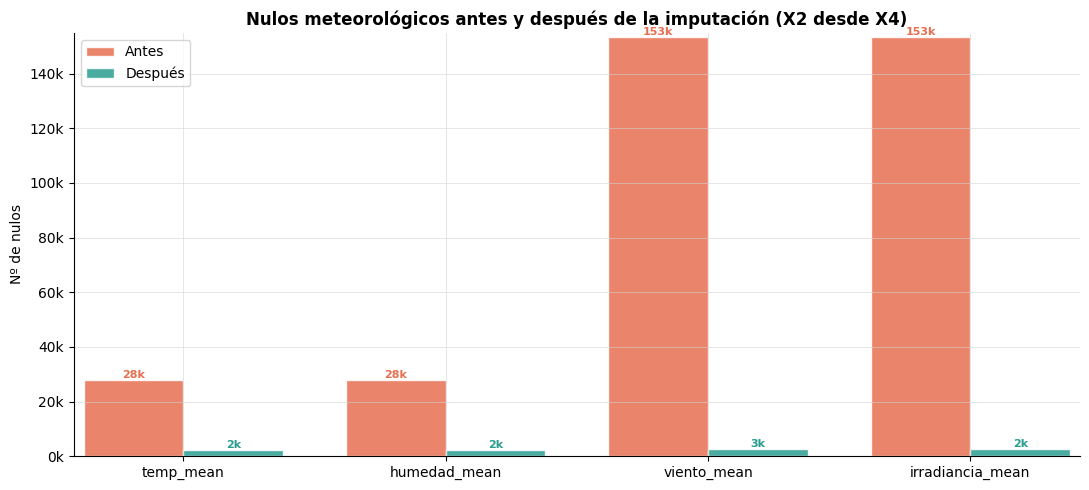

In [6]:
vars_imp = ['temp_mean', 'humedad_mean', 'viento_mean', 'irradiancia_mean']
pre  = [nulos_pre[v] for v in vars_imp]
post = [df[v].null_count() for v in vars_imp]

x = np.arange(len(vars_imp))
w = 0.38
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - w/2, pre,  width=w, color=C5, alpha=0.85, label='Antes',   edgecolor='white')
ax.bar(x + w/2, post, width=w, color=C2, alpha=0.85, label='Después', edgecolor='white')
for i, (a, b) in enumerate(zip(pre, post)):
    ax.text(i - w/2, a, f'{a/1000:.0f}k', ha='center', va='bottom', fontsize=8, color=C5, fontweight='bold')
    ax.text(i + w/2, b, f'{b/1000:.0f}k', ha='center', va='bottom', fontsize=8, color=C2, fontweight='bold')
ax.set_title('Nulos meteorológicos antes y después de la imputación (X2 desde X4)', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(vars_imp)
ax.set_ylabel('Nº de nulos')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v/1000:.0f}k'))
ax.legend()
plt.tight_layout(); plt.show()

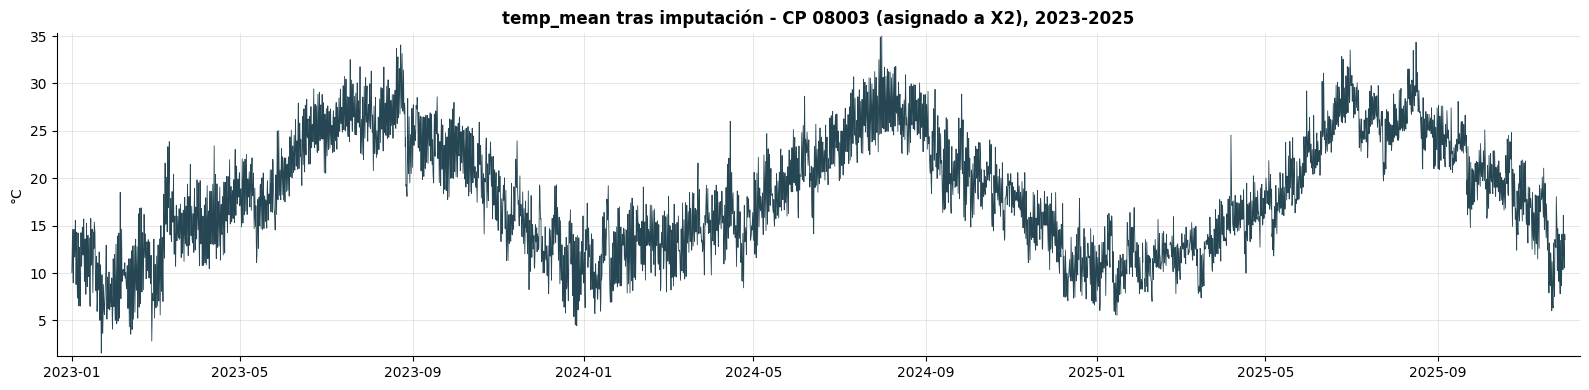

In [7]:
# Continuidad de la serie imputada en un CP asignado a X2
cp_x2 = df.filter(pl.col('codi_estacio') == 'X2')['cod_postal'].unique().sort()[0]

serie = (
    df.filter((pl.col('cod_postal') == cp_x2) & (pl.col('anio') >= 2023))
    .sort('datetime').select(['datetime', 'temp_mean'])
)

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(serie['datetime'].to_numpy(), serie['temp_mean'].to_numpy(), color=C1, linewidth=0.6)
ax.set_title(f'temp_mean tras imputación - CP {cp_x2} (asignado a X2), 2023-2025', fontweight='bold')
ax.set_ylabel('°C')
plt.tight_layout(); plt.show()

> - Las variables meteorológicas pasan de un 6% y  36% de nulos a casi 0. 

- La imputación de X2 con ratio mensual cubre el grueso y el fallback desde X4 limpia los nulos esporádicos de D5 y X8. Esto se hace consciente del posible sesgo que se puede introducir pero al ser un porcetntaje muy epqueño de los datos se decide seguir adelante con esta imputación.

Solo quedan los pocos bloques en que la propia X4 tampoco tenía lectura.
 - La serie temporal del CP de X2 no presenta cortes en 2024-2025 y conserva el ciclo estacional esperado (frío en invierno, cálido en verano), señal de que el factor de corrección mensual reproduce un perfil físicamente coherente y no un parche plano.

---
# <font color='#1B3A5C'>  **2. Variables Climáticas Derivadas** </font>

### <font color='#C0392B'><b>2.1 HDD Y CDD</b></font>

> El EDA mostró que la relación entre temperatura y consumo es no lineal (forma en U) por lo que el consumo sube tanto en frío (calefacción) como en calor (refrigeración). 

Un modelo lineal no va  a capturar esa forma con temp_mean cruda. Los grados-día descomponen la U en dos rampas lineales:

- **HDD (Heating Degree Days)** = max(0, 15 − temp_mean). Responde a la pregunta ¿cuánto frío hay por debajo de 15°C?
- **CDD (Cooling Degree Days)** = max(0, temp_mean − 22). Responde a la pregunta ¿cuánto calor hay por encima de 22°C?
- **cdd_roll_3d (inercia térmica)** = media móvil del CDD de los últimos 3 días (12 bloques de 6h) por CP. Responde a la pregunta ¿cuánto calor se ha acumulado en los últimos días?

> El uso de grados-día se apoya en [Kuru & Calis 2019], aunque su estudio es sobre Francia y solo modela calefacción (HDD). Los umbrales 15°C y 22°C siguen el estándar europeo de Eurostat (que fija el umbral de HDD en 15°C) y la evidencia para el clima mediterráneo español, donde la refrigeración (CDD) sí tiene un peso relevante que justifica incluirla. El 22°C del CDD se apoya además en [Giannakopoulos & Psiloglou 2006], que identificaron esa temperatura como la de mínimo consumo energético en Atenas, ciudad de clima mediterráneo como Barcelona. 

> Por qué la inercia térmica (cdd_roll_3d):

El consumo de refrigeración no depende solo del calor de hoy: los edificios acumulan calor y el tercer día de una ola consume más que el primero a igual temperatura. El EDA ya distinguía los picos reales de los errores por ese crecimiento gradual sostenido (08013, 08036). El CDD puntual no ve esa acumulación; una media móvil de 3 días sí. Un modelo de árboles (XGBoost/LightGBM) no puede derivarla solo, porque opera fila a fila y solo dispone del CDD del bloque actual, no del de los días anteriores; igual que los lags, hay que dársela ya calculada. El efecto rezagado de la temperatura sobre la demanda eléctrica está documentado para España en [Pardo, Meneu & Valor 2002], que prueba que la especificación dinámica de la temperatura es significativa incluso controlando los efectos autorregresivos. 

In [8]:
df = df.with_columns([
    pl.when(pl.col('temp_mean').is_null()).then(pl.lit(None).cast(pl.Float64))
      .when(15 - pl.col('temp_mean') > 0).then(15 - pl.col('temp_mean'))
      .otherwise(0.0).alias('HDD'),
    pl.when(pl.col('temp_mean').is_null()).then(pl.lit(None).cast(pl.Float64))
      .when(pl.col('temp_mean') - 22 > 0).then(pl.col('temp_mean') - 22)
      .otherwise(0.0).alias('CDD'),
    pl.col('lst_celsius').is_null().cast(pl.Int8).alias('lst_nublado'),
    (pl.col('precipitacion_sum') > 0).cast(pl.Int8).alias('precipitacion_llueve'),
])

# Inercia térmica: media móvil del CDD de los últimos 3 días (12 bloques de 6h) por CP.
# Captura el calor ACUMULADO de una ola que el CDD puntual no ve. Requiere orden temporal.
df = df.sort(['cod_postal', 'datetime']).with_columns(
    pl.col('CDD').rolling_mean(window_size=12).over('cod_postal').alias('cdd_roll_3d')
)

print(df.select(['temp_mean', 'HDD', 'CDD', 'cdd_roll_3d', 'lst_celsius', 'lst_nublado',
                 'precipitacion_sum', 'precipitacion_llueve']).head(8))

print(f"\nlst_nublado = 1:          {df['lst_nublado'].sum():>8,}  ({df['lst_nublado'].mean()*100:.1f}%)")
print(f"precipitacion_llueve = 1: {df['precipitacion_llueve'].sum():>8,}  ({df['precipitacion_llueve'].mean()*100:.1f}%)")

shape: (8, 8)
┌───────────┬──────────┬─────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────────┐
│ temp_mean ┆ HDD      ┆ CDD ┆ cdd_roll_3d ┆ lst_celsius ┆ lst_nublado ┆ precipitaci ┆ precipitaci │
│ ---       ┆ ---      ┆ --- ┆ ---         ┆ ---         ┆ ---         ┆ on_sum      ┆ on_llueve   │
│ f64       ┆ f64      ┆ f64 ┆ f64         ┆ f64         ┆ i8          ┆ ---         ┆ ---         │
│           ┆          ┆     ┆             ┆             ┆             ┆ f64         ┆ i8          │
╞═══════════╪══════════╪═════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╡
│ 9.883333  ┆ 5.116667 ┆ 0.0 ┆ null        ┆ 12.57       ┆ 0           ┆ 0.0         ┆ 0           │
│ 12.775    ┆ 2.225    ┆ 0.0 ┆ null        ┆ 12.57       ┆ 0           ┆ 0.0         ┆ 0           │
│ 14.65     ┆ 0.35     ┆ 0.0 ┆ null        ┆ 12.57       ┆ 0           ┆ 0.0         ┆ 0           │
│ 11.841667 ┆ 3.158333 ┆ 0.0 ┆ null        ┆ 12.57       ┆ 0           ┆ 0.0 

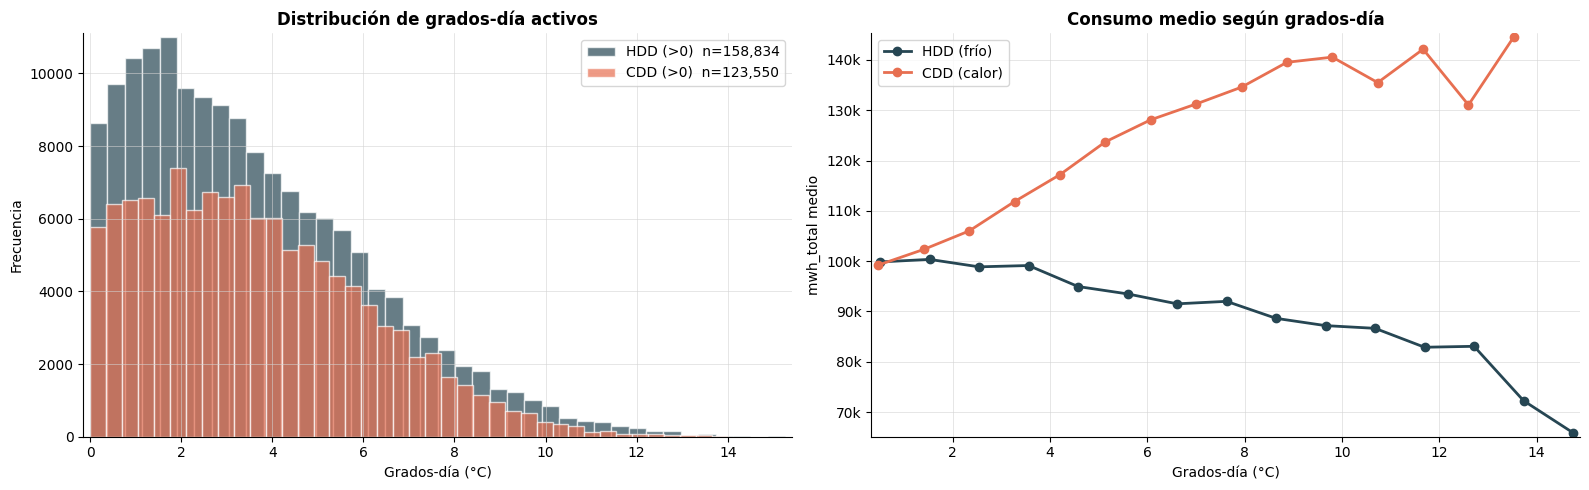

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribución de grados-día (solo valores activos > 0)
hdd = df.filter(pl.col('HDD') > 0)['HDD'].to_numpy()
cdd = df.filter(pl.col('CDD') > 0)['CDD'].to_numpy()
axes[0].hist(hdd, bins=40, color=C1, alpha=0.7, label=f'HDD (>0)  n={len(hdd):,}', edgecolor='white')
axes[0].hist(cdd, bins=40, color=C5, alpha=0.7, label=f'CDD (>0)  n={len(cdd):,}', edgecolor='white')
axes[0].set_title('Distribución de grados-día activos', fontweight='bold')
axes[0].set_xlabel('Grados-día (°C)'); axes[0].set_ylabel('Frecuencia'); axes[0].legend()

# Relación con el consumo
d = df.select(['HDD', 'CDD', 'mwh_total']).to_pandas()
for col, color, lab in [('HDD', C1, 'HDD (frío)'), ('CDD', C5, 'CDD (calor)')]:
    sub = d[d[col] > 0].copy()
    sub['bin'] = pd.cut(sub[col], bins=15)
    g = sub.groupby('bin', observed=True)['mwh_total'].mean().reset_index()
    g['centro'] = g['bin'].apply(lambda x: x.mid)
    axes[1].plot(g['centro'], g['mwh_total'], marker='o', color=color, linewidth=2, label=lab)
axes[1].set_title('Consumo medio según grados-día', fontweight='bold')
axes[1].set_xlabel('Grados-día (°C)'); axes[1].set_ylabel('mwh_total medio')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v/1000:.0f}k'))
axes[1].legend()
plt.tight_layout(); plt.show()

> Tanto HDD como CDD muestran un consumo creciente al alejarse de la zona de confort (entre 15 y 22°C), lo que valida la descomposición de la U térmica en dos rampas lineales que un modelo de árboles o lineal sí que puede aprovechar.
    
    - Aunque, la rampa de CDD es más pronunciada que la de HDD. La refrigeración durante épocas de calor dispara el consumo eléctrico con más fuerza que la calefacción.

> En cuanto a sí se ha nublado el día, lst_nublado recoge el ~40% de bloques sin cobertura MODIS y precipitacion_llueve marca los bloques con lluvia, ambas como señal binaria limpia.
> - HDD y CDD quedan como null (no 0) en los pocos bloques sin temperatura, para no introducir un falso "día de confort" donde en realidad falta el dato.

### <font color='#C0392B'><b>2.1 LST Y Nubosidad</b></font>

Nulos de LST, lluvia y humedad por mes
shape: (12, 4)
┌─────┬──────────────┬────────────┬───────────────┐
│ mes ┆ pct_lst_nulo ┆ pct_llueve ┆ humedad_media │
│ --- ┆ ---          ┆ ---        ┆ ---           │
│ i64 ┆ f64          ┆ f64        ┆ f64           │
╞═════╪══════════════╪════════════╪═══════════════╡
│ 1   ┆ 42.3         ┆ 5.4        ┆ 63.8          │
│ 2   ┆ 47.4         ┆ 6.3        ┆ 69.9          │
│ 3   ┆ 49.4         ┆ 9.6        ┆ 69.2          │
│ 4   ┆ 43.9         ┆ 9.4        ┆ 68.1          │
│ 5   ┆ 33.7         ┆ 7.9        ┆ 67.8          │
│ …   ┆ …            ┆ …          ┆ …             │
│ 8   ┆ 25.9         ┆ 4.8        ┆ 67.0          │
│ 9   ┆ 43.7         ┆ 9.5        ┆ 68.9          │
│ 10  ┆ 46.5         ┆ 7.6        ┆ 72.6          │
│ 11  ┆ 47.8         ┆ 6.7        ┆ 67.8          │
│ 12  ┆ 45.8         ┆ 5.7        ┆ 67.6          │
└─────┴──────────────┴────────────┴───────────────┘

% de LST nulo segun si llueve (0=seco, 1=lluvia)
shape: (3, 2

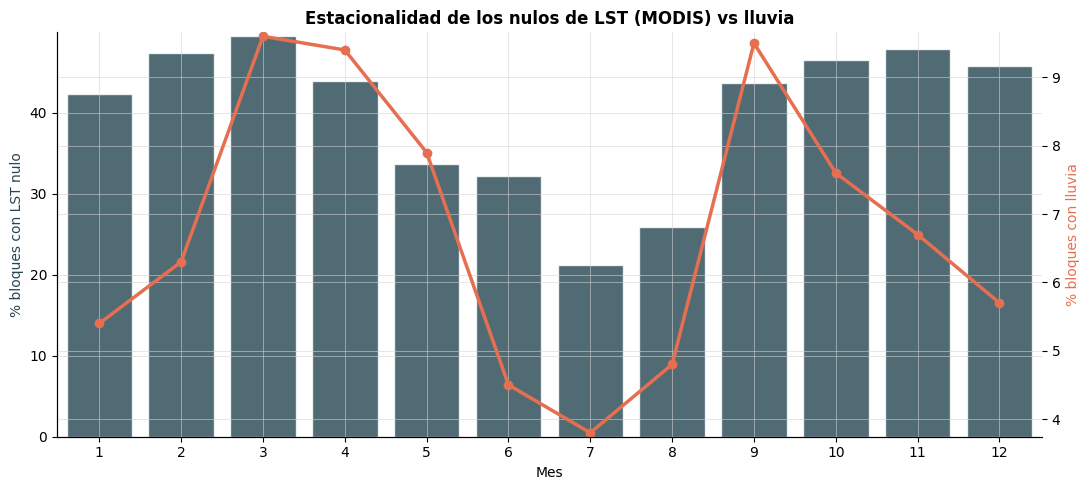

In [10]:
#  Verificación: ¿los nulos de LST coinciden con días nublados?

# 1) % de nulos de LST por mes (esperado: más en otoño-invierno)
nubes_mes = (
    df.group_by('mes')
    .agg([
        pl.col('lst_nublado').mean().mul(100).round(1).alias('pct_lst_nulo'),
        pl.col('precipitacion_llueve').mean().mul(100).round(1).alias('pct_llueve'),
        pl.col('humedad_mean').mean().round(1).alias('humedad_media'),
    ])
    .sort('mes')
)
print("Nulos de LST, lluvia y humedad por mes")
print(nubes_mes)

# 2) ¿Hay más nulos de LST cuando llueve? (prueba directa de la hipótesis "nubes")
cruce = (
    df.group_by('precipitacion_llueve')
    .agg(pl.col('lst_nublado').mean().mul(100).round(1).alias('pct_lst_nulo'))
    .sort('precipitacion_llueve')
)
print("\n% de LST nulo segun si llueve (0=seco, 1=lluvia)")
print(cruce)

# 3) Gráfico: estacionalidad de los nulos de LST vs lluvia
m = nubes_mes.to_pandas()
fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.bar(m['mes'], m['pct_lst_nulo'], color=C1, alpha=0.8, edgecolor='white', label='% LST nulo')
ax1.set_xlabel('Mes'); ax1.set_ylabel('% bloques con LST nulo', color=C1)
ax1.set_xticks(range(1, 13))

ax2 = ax1.twinx()
ax2.plot(m['mes'], m['pct_llueve'], color=C5, marker='o', linewidth=2.5, label='% llueve')
ax2.set_ylabel('% bloques con lluvia', color=C5)

ax1.set_title('Estacionalidad de los nulos de LST (MODIS) vs lluvia', fontweight='bold')
plt.tight_layout(); plt.show()

- lst_nublado = 1 si lst_celsius es nulo. Convierte la falta de cobertura MODIS (nubes) en señal informativa en lugar de un hueco.
- precipitacion_llueve = 1 si precipitacion_sum > 0. El EDA confirmó que la información útil está en si llueve o no, no en la cantidad de preciítación(ambas medianas en 0).

Fila null: De los bloques donde no sé si llovió, el 30.9% tienen LST nulo.
Fila 0: De los bloques secos, el 37.2% tienen LST nulo.
Fila 1: De los bloques con lluvia, el 76.3% tienen LST nulo.

> La hipótesis de que los nulos de LST corresponden a nubosidad queda confirmada. 
- Cuando llueve, MODIS no reporta lectura en el 76.3% de los bloques, frente al 37.2% en condiciones secas, más del doble. 
- La estacionalidad lo refuerza, con un mínimo claro de nulos en julio 21% y agosto de 26%, los meses de cielo despejado del verano, frente al 42 a 49% del resto del año.

> El acoplamiento con la lluvia es fuerte pero no perfecto.
- En invierno hay muchos nulos aproximadamente 45% con poca lluvia, porque la nubosidad y la bruma sin precipitación también bloquean la señal del satélite. 

El flag lst_nublado captura por tanto la nubosidad en sentido amplio, validando su uso como señal informativa en lugar de tratar el nulo como un simple hueco.

---
# <font color='#1B3A5C'>  **3. Lags Temporales y Media Móvil** </font>

> En el análisis ACF/PACF del EDA se identificaron los lags más informativos. Se construye por código postal (cada CP es una serie temporal independiente) y ordenados por datetime para no mezclar barrios ni romper la cronología:

- **lag_1** (6h antes): contribución directa PACF 0.37.
- **lag_2**, **lag_3** (12h, 18h antes): completan el día anterior; PACF lag_3 = 0.47, contribución directa fuerte.
- **lag_4** (24h antes): la más fuerte, PACF 0.75. Mismo bloque del día anterior.
- **lag_28** (7 días antes): ACF 0.87, patrón semanal completo.
- **rolling_mean_7d**: media de los últimos 7 días (28 bloques), desplazada un bloque para no
  incluir el valor actual y evitar data leakage.
- **rolling_std_7d**: desviación estándar de los últimos 7 días (mismo desfase). Volatilidad reciente, clave para la fase de alerta temprana.

> Los lags generan nulos en los primeros bloques de cada serie (hasta 28 para lag_28). Es
> esperado y se gestiona en modelado: los árboles toleran nulos; para SARIMA/LSTM se recortan
> los primeros registros.

In [11]:
df = df.sort(['cod_postal', 'datetime'])

df = df.with_columns([
    pl.col('mwh_total').shift(1).over('cod_postal').alias('lag_1'),
    pl.col('mwh_total').shift(2).over('cod_postal').alias('lag_2'),
    pl.col('mwh_total').shift(3).over('cod_postal').alias('lag_3'),
    pl.col('mwh_total').shift(4).over('cod_postal').alias('lag_4'),
    pl.col('mwh_total').shift(28).over('cod_postal').alias('lag_28'),
    pl.col('mwh_total').shift(1).rolling_mean(window_size=28).over('cod_postal').alias('rolling_mean_7d'),
    pl.col('mwh_total').shift(1).rolling_std(window_size=28).over('cod_postal').alias('rolling_std_7d'),
])

cp_demo = df['cod_postal'].first()
print(f"Ejemplo de lags — CP {cp_demo}")
print(df.filter(pl.col('cod_postal') == cp_demo)
        .select(['datetime', 'mwh_total', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_28', 'rolling_mean_7d', 'rolling_std_7d'])
        .head(8))

print("\nNulos generados por los lags (primeros bloques de cada CP)")
for v in ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_28', 'rolling_mean_7d', 'rolling_std_7d']:
    print(f"  {v:<18} {df[v].null_count():>6,}")

Ejemplo de lags — CP 08001
shape: (8, 9)
┌─────────────┬───────────┬──────────┬──────────┬───┬──────────┬────────┬─────────────┬────────────┐
│ datetime    ┆ mwh_total ┆ lag_1    ┆ lag_2    ┆ … ┆ lag_4    ┆ lag_28 ┆ rolling_mea ┆ rolling_st │
│ ---         ┆ ---       ┆ ---      ┆ ---      ┆   ┆ ---      ┆ ---    ┆ n_7d        ┆ d_7d       │
│ datetime[μs ┆ f64       ┆ f64      ┆ f64      ┆   ┆ f64      ┆ f64    ┆ ---         ┆ ---        │
│ ]           ┆           ┆          ┆          ┆   ┆          ┆        ┆ f64         ┆ f64        │
╞═════════════╪═══════════╪══════════╪══════════╪═══╪══════════╪════════╪═════════════╪════════════╡
│ 2019-01-01  ┆ 68681.0   ┆ null     ┆ null     ┆ … ┆ null     ┆ null   ┆ null        ┆ null       │
│ 00:00:00    ┆           ┆          ┆          ┆   ┆          ┆        ┆             ┆            │
│ 2019-01-01  ┆ 84009.0   ┆ 68681.0  ┆ null     ┆ … ┆ null     ┆ null   ┆ null        ┆ null       │
│ 06:00:00    ┆           ┆          ┆          ┆ 

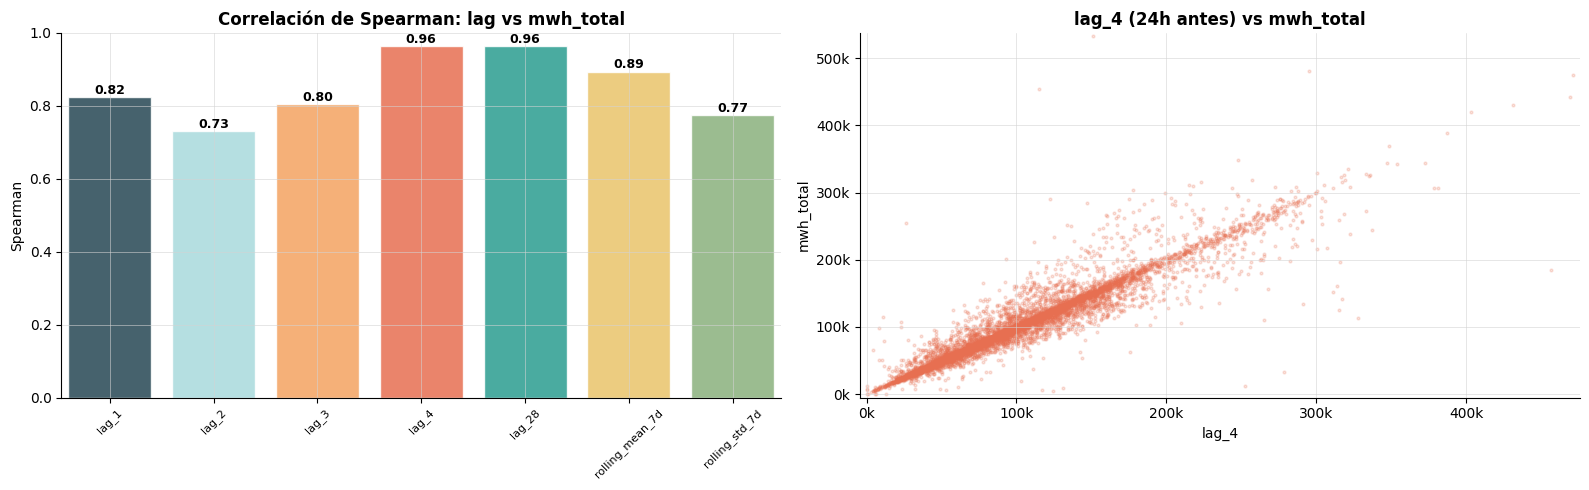

In [12]:
lags = ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_28', 'rolling_mean_7d', 'rolling_std_7d']
corrs = []
for v in lags:
    d = df.select([v, 'mwh_total']).drop_nulls()
    corrs.append(spearmanr(d[v].to_numpy(), d['mwh_total'].to_numpy()).statistic)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

bars = axes[0].bar(lags, corrs, color=[C1, C6, C4, C5, C2, C3, '#8AB17D'], alpha=0.85, edgecolor='white')
for b, c in zip(bars, corrs):
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
                 f'{c:.2f}', ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('Correlación de Spearman: lag vs mwh_total', fontweight='bold')
axes[0].set_ylabel('Spearman'); axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=45, labelsize=8)

d = df.select(['lag_4', 'mwh_total']).drop_nulls().sample(n=8000, seed=42)
axes[1].scatter(d['lag_4'].to_numpy(), d['mwh_total'].to_numpy(), s=4, alpha=0.2, color=C5)
axes[1].set_title('lag_4 (24h antes) vs mwh_total', fontweight='bold')
axes[1].set_xlabel('lag_4'); axes[1].set_ylabel('mwh_total')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v/1000:.0f}k'))
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v/1000:.0f}k'))
plt.tight_layout(); plt.show()

> - lag_4 y rolling_mean_7d son los predictores más fuertes (Spearman muy alto), confirmando
>   el peso del mismo bloque del día anterior y de la tendencia reciente de 7 días.
> - lag_28 mantiene una correlación elevada por el patrón semanal, y lag_1 aporta la señal
>   inmediata aunque algo menor.
> - El scatter de lag_4 vs mwh_total se alinea casi en la diagonal: el consumo de hace 24h es
>   un predictor casi directo, lo que anticipa una alta importancia de esta feature en el modelado.
> - lag_2 y lag_3 completan el perfil del día anterior, y rolling_std_7d resume la volatilidad reciente
>   (señal pensada para la detección de picos en la fase de alerta temprana).

---
# <font color='#1B3A5C'>  **4. Variables de Interacción y Control** </font>


>  El efecto de "ser finde" DEPENDE de la hora. El heatmap hora × día del EDA mostró que el efecto del día de la semana depende del bloque horario. A las 00h el consumo es casi constante toda la semana, pero a las 12h la brecha entre miércoles y domingo supera el 24%. Una hora y un es_finde independientes no capturan esa amplificación diurna:

- **hora_x_finde** = hora × es_finde: interacción que distingue el perfil horario del fin de semana del laborable. Pensada para XGBoost y LightGBM.
- **is_covid** = 1 si anio == 2020: controla el cambio estructural por la pandemia (caída ~12%
  documentada en el EDA), para que el modelo no lo confunda con estacionalidad.

In [13]:
df = df.with_columns([
    (pl.col('hora') * pl.col('es_finde')).alias('hora_x_finde'),
    (pl.col('anio') == 2020).cast(pl.Int8).alias('is_covid'),
])

print(df.select(['hora', 'es_finde', 'hora_x_finde', 'anio', 'is_covid'])
        .unique().sort(['anio', 'hora', 'es_finde']).head(12))

print(f"\nis_covid = 1: {df['is_covid'].sum():,} registros ({df['is_covid'].mean()*100:.1f}%)")

shape: (12, 5)
┌──────┬──────────┬──────────────┬──────┬──────────┐
│ hora ┆ es_finde ┆ hora_x_finde ┆ anio ┆ is_covid │
│ ---  ┆ ---      ┆ ---          ┆ ---  ┆ ---      │
│ i64  ┆ i64      ┆ i64          ┆ i64  ┆ i8       │
╞══════╪══════════╪══════════════╪══════╪══════════╡
│ 0    ┆ 0        ┆ 0            ┆ 2019 ┆ 0        │
│ 0    ┆ 1        ┆ 0            ┆ 2019 ┆ 0        │
│ 6    ┆ 0        ┆ 0            ┆ 2019 ┆ 0        │
│ 6    ┆ 1        ┆ 6            ┆ 2019 ┆ 0        │
│ 12   ┆ 0        ┆ 0            ┆ 2019 ┆ 0        │
│ …    ┆ …        ┆ …            ┆ …    ┆ …        │
│ 18   ┆ 1        ┆ 18           ┆ 2019 ┆ 0        │
│ 0    ┆ 0        ┆ 0            ┆ 2020 ┆ 1        │
│ 0    ┆ 1        ┆ 0            ┆ 2020 ┆ 1        │
│ 6    ┆ 0        ┆ 0            ┆ 2020 ┆ 1        │
│ 6    ┆ 1        ┆ 6            ┆ 2020 ┆ 1        │
└──────┴──────────┴──────────────┴──────┴──────────┘

is_covid = 1: 61,488 registros (14.5%)


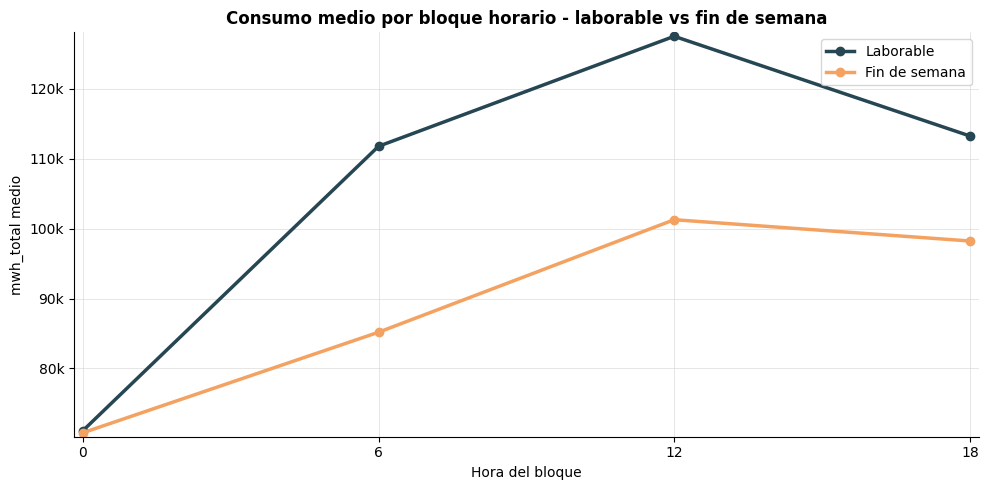

In [14]:
inter = (
    df.group_by(['hora', 'es_finde'])
    .agg(pl.col('mwh_total').mean().alias('m'))
    .sort(['hora', 'es_finde'])
)

fig, ax = plt.subplots(figsize=(10, 5))
for fv, color, lab in [(0, C1, 'Laborable'), (1, C4, 'Fin de semana')]:
    s = inter.filter(pl.col('es_finde') == fv).sort('hora')
    ax.plot(s['hora'].to_numpy(), s['m'].to_numpy(), marker='o', color=color, linewidth=2.5, label=lab)
ax.set_title('Consumo medio por bloque horario - laborable vs fin de semana', fontweight='bold')
ax.set_xlabel('Hora del bloque'); ax.set_ylabel('mwh_total medio')
ax.set_xticks([0, 6, 12, 18])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v/1000:.0f}k'))
ax.legend()
plt.tight_layout(); plt.show()

> - Las dos curvas casi coinciden en el bloque de 00h y divergen con fuerza en los bloques
>   diurnos (12h), exactamente la amplificación que el modelo no vería con hora y es_finde
>   por separado. hora_x_finde codifica esa diferencia en una sola variable.
> - is_covid aísla el año 2020 como cambio estructural puntual, evitando que el modelo
>   interprete la caída de la pandemia como un patrón recurrente.

---
# <font color='#1B3A5C'>  **5. Perfil Sectorial por Código Postal** </font>

> El EDA mostró que cada código postal tiene una identidad sectorial propia (servicios, industria o residencial) que determina su patrón de consumo: los barrios de servicios pican en verano por refrigeración, los residenciales en invierno por calefacción y los industriales se mantienen estables. Esta composición es la fuente de la heterogeneidad de 8x entre barrios y de que cod_postal sea el factor más discriminante del dataset.

Los sectores mwh_industria, mwh_residencial y mwh_servicios no pueden entrar como features porque son componentes directos del target (data leakage). La solución es resumir la identidad del barrio en su proporción sectorial histórica, calculada de forma causal:

- **pct_industria_cp**, **pct_residencial_cp**, **pct_servicios_cp** = proporción de cada sector sobre el consumo de los 12 meses anteriores a cada bloque (media móvil rezagada por CP, sobre industria + residencial + servicios; mwh_no_especificado se ignora por su 85% de nulos).

> Por qué una ventana rezagada de 12 meses y no del mes anterior:

- **Sin data leakage**: usa solo los 12 meses previos, nunca el mes actual ni el futuro, así que es causal igual que un lag. Al calcularse fila a fila sobre el pasado, además es independiente del punto de corte train/test: cambiar el horizonte no la invalida ni obliga a recalcularla.
- **Cancela la estacionalidad**: el porcentaje de un solo mes reintroduciría el ciclo estacional (servicios sube en verano por aire acondicionado, residencial en invierno por calefacción), señal que ya capturan mes, HDD y CDD. Una ventana de 12 meses abarca un ciclo anual completo, por lo que la estacionalidad se promedia y se cancela, dejando solo la identidad estructural del barrio.
- **Capta la deriva estructural**: si un barrio se transforma lentamente (como la reconversión de El Poblenou hacia oficinas y tecnología documentada en el EDA), el perfil rodante lo refleja de forma suave, sin el ruido de un único mes.

In [15]:
# Agregado mensual de sectores por CP
mensual_sec = (
    df.with_columns(pl.col('datetime').dt.truncate('1mo').alias('anio_mes'))
    .group_by(['cod_postal', 'anio_mes'])
    .agg([
        pl.col('mwh_industria').sum().alias('sum_ind'),
        pl.col('mwh_residencial').sum().alias('sum_res'),
        pl.col('mwh_servicios').sum().alias('sum_serv'),
    ])
    .sort(['cod_postal', 'anio_mes'])
)

# Ventana rezagada de 12 meses por CP (shift 1 mes -> excluye el mes actual, sin leakage)
mensual_sec = mensual_sec.with_columns([
    pl.col('sum_ind').shift(1).rolling_sum(window_size=12).over('cod_postal').alias('roll_ind'),
    pl.col('sum_res').shift(1).rolling_sum(window_size=12).over('cod_postal').alias('roll_res'),
    pl.col('sum_serv').shift(1).rolling_sum(window_size=12).over('cod_postal').alias('roll_serv'),
]).with_columns(
    (pl.col('roll_ind') + pl.col('roll_res') + pl.col('roll_serv')).alias('roll_tot')
).with_columns([
    (pl.col('roll_ind')  / pl.col('roll_tot')).alias('pct_industria_cp'),
    (pl.col('roll_res')  / pl.col('roll_tot')).alias('pct_residencial_cp'),
    (pl.col('roll_serv') / pl.col('roll_tot')).alias('pct_servicios_cp'),
])

# Unir el perfil al dataset por CP y mes
df = (
    df.with_columns(pl.col('datetime').dt.truncate('1mo').alias('anio_mes'))
    .join(
        mensual_sec.select(['cod_postal', 'anio_mes',
                            'pct_industria_cp', 'pct_residencial_cp', 'pct_servicios_cp']),
        on=['cod_postal', 'anio_mes'], how='left'
    )
    .drop('anio_mes')
)

PERFIL = ['pct_industria_cp', 'pct_residencial_cp', 'pct_servicios_cp']
print("Nulos del perfil sectorial (primer año de cada CP, sin 12 meses de histórico)")
for v in PERFIL:
    n = df[v].null_count()
    print(f"  {v:<22} {n:>7,}  ({n/len(df)*100:.2f}%)")

print("\nPerfil sectorial (último valor disponible) en 4 CPs representativos")
print(
    df.filter(pl.col('cod_postal').is_in(['08038', '08005', '08032', '08002']))
    .group_by('cod_postal')
    .agg([pl.col(v).last().round(3) for v in PERFIL])
    .sort('cod_postal')
)

Nulos del perfil sectorial (primer año de cada CP, sin 12 meses de histórico)
  pct_industria_cp        61,320  (14.45%)
  pct_residencial_cp      61,320  (14.45%)
  pct_servicios_cp        61,320  (14.45%)

Perfil sectorial (último valor disponible) en 4 CPs representativos
shape: (4, 4)
┌────────────┬──────────────────┬────────────────────┬──────────────────┐
│ cod_postal ┆ pct_industria_cp ┆ pct_residencial_cp ┆ pct_servicios_cp │
│ ---        ┆ ---              ┆ ---                ┆ ---              │
│ str        ┆ f64              ┆ f64                ┆ f64              │
╞════════════╪══════════════════╪════════════════════╪══════════════════╡
│ 08002      ┆ 0.042            ┆ 0.252              ┆ 0.707            │
│ 08005      ┆ 0.028            ┆ 0.317              ┆ 0.655            │
│ 08032      ┆ 0.01             ┆ 0.702              ┆ 0.287            │
│ 08038      ┆ 0.256            ┆ 0.233              ┆ 0.511            │
└────────────┴──────────────────┴───────────

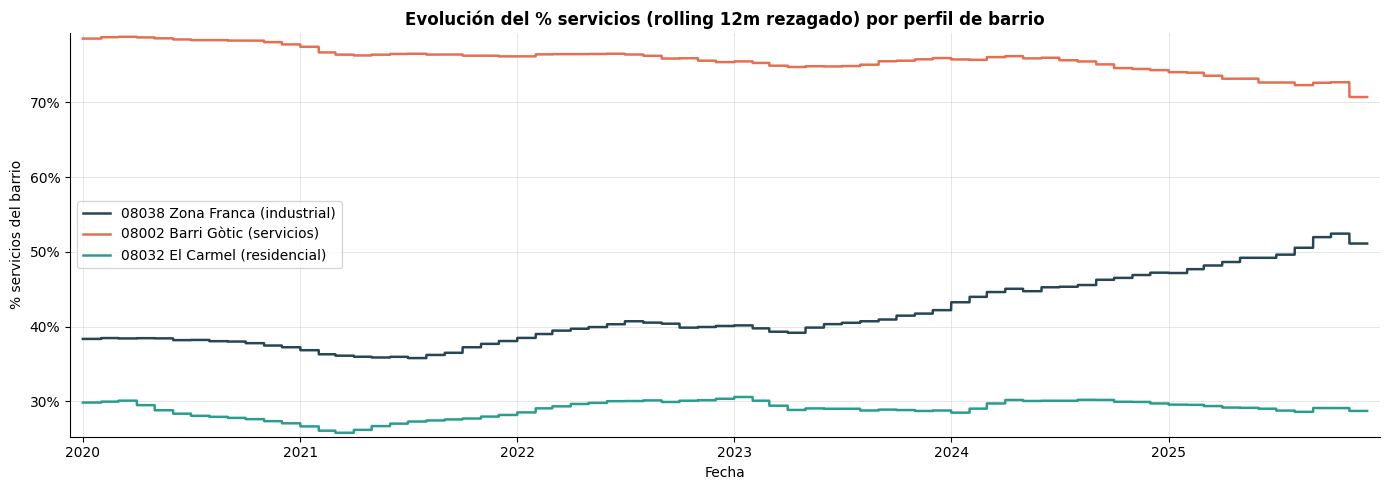

In [16]:
fig, ax = plt.subplots(figsize=(14, 5))
cps_demo = {'08038': ('Zona Franca (industrial)', C1),
            '08002': ('Barri Gòtic (servicios)', C5),
            '08032': ('El Carmel (residencial)', C2)}
for cp, (lab, color) in cps_demo.items():
    s = (df.filter(pl.col('cod_postal') == cp)
           .sort('datetime')
           .select(['datetime', 'pct_servicios_cp']).drop_nulls().unique('datetime', maintain_order=True))
    ax.plot(s['datetime'].to_numpy(), s['pct_servicios_cp'].to_numpy(),
            color=color, linewidth=1.8, label=f'{cp} {lab}')
ax.set_title('Evolución del % servicios (rolling 12m rezagado) por perfil de barrio', fontweight='bold')
ax.set_ylabel('% servicios del barrio'); ax.set_xlabel('Fecha')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v*100:.0f}%'))
ax.legend()
plt.tight_layout(); plt.show()

> El perfil sectorial separa con claridad los tres regímenes del EDA: el Barri Gòtic se mantiene en torno al 75% de servicios, El Carmel domina en residencial y la Zona Franca concentra la mayor proporción industrial. Las curvas son planas dentro de cada barrio (la identidad estructural es estable) y solo derivan de forma lenta donde hay reconversión real, lo que confirma que la ventana de 12 meses captura el carácter del barrio sin contaminarse de estacionalidad.

> Los nulos corresponden al primer año de cada CP (sin 12 meses previos de histórico), comportamiento idéntico al de los lags y gestionado igual en el modelado: los árboles los toleran y para SARIMA/LSTM se recortan los primeros registros.

---
# <font color='#1B3A5C'>  **6. Dataset Final y Guardado** </font>

### <font color='#C0392B'><b>6.1 Resumen de features construidas</b></font>

| Feature | Tipo | Definición |
|---|---|---|
| `HDD` | Numérica | max(0, 15 − temp_mean), grados de calefacción |
| `CDD` | Numérica | max(0, temp_mean − 22), grados de refrigeración |
| `cdd_roll_3d` | Numérica | media móvil del CDD de 3 días por CP (inercia térmica) |
| `lst_nublado` | Binaria | 1 si lst_celsius es nulo (sin cobertura MODIS) |
| `precipitacion_llueve` | Binaria | 1 si precipitacion_sum > 0 |
| `lag_1` | Numérica | mwh_total 6h antes (por CP) |
| `lag_2` | Numérica | mwh_total 12h antes (por CP) |
| `lag_3` | Numérica | mwh_total 18h antes (por CP) |
| `lag_4` | Numérica | mwh_total 24h antes (por CP) |
| `lag_28` | Numérica | mwh_total 7 días antes (por CP) |
| `rolling_mean_7d` | Numérica | media móvil de 7 días, desplazada 1 bloque |
| `rolling_std_7d` | Numérica | desviación móvil de 7 días (volatilidad reciente) |
| `hora_x_finde` | Numérica | hora × es_finde |
| `is_covid` | Binaria | 1 si anio == 2020 |
| `pct_industria_cp` | Numérica | % industria del CP, media móvil 12m rezagada |
| `pct_residencial_cp` | Numérica | % residencial del CP, media móvil 12m rezagada |
| `pct_servicios_cp` | Numérica | % servicios del CP, media móvil 12m rezagada |

In [17]:
FEATURES_NUEVAS = ['HDD', 'CDD', 'cdd_roll_3d', 'lst_nublado', 'precipitacion_llueve',
                   'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_28',
                   'rolling_mean_7d', 'rolling_std_7d',
                   'hora_x_finde', 'is_covid',
                   'pct_industria_cp', 'pct_residencial_cp', 'pct_servicios_cp']

print(f"Shape final: {df.shape}")
print(f"Columnas ({len(df.columns)}): {df.columns}\n")

print("Resumen de las features numéricas nuevas")
print(df.select(['HDD', 'CDD', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_28', 'rolling_mean_7d', 'rolling_std_7d']).describe())

print("\nNulos por feature nueva")
for v in FEATURES_NUEVAS:
    n = df[v].null_count()
    print(f"  {v:<22} {n:>6,}  ({n/len(df)*100:.2f}%)")

Shape final: (424368, 47)
Columnas (47): ['cod_postal', 'nombre_postal', 'centroide_lon', 'centroide_lat', 'codi_estacio', 'nombre_estacio', 'estacio_lon', 'estacio_lat', 'datetime', 'mwh_total', 'mwh_industria', 'mwh_residencial', 'mwh_servicios', 'mwh_no_especificado', 'lst_celsius', 'temp_mean', 'temp_max', 'temp_min', 'humedad_mean', 'viento_mean', 'precipitacion_sum', 'irradiancia_mean', 'es_festivo', 'nombre_local', 'hora', 'dia_semana', 'mes', 'anio', 'semana_anio', 'es_finde', 'HDD', 'CDD', 'lst_nublado', 'precipitacion_llueve', 'cdd_roll_3d', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_28', 'rolling_mean_7d', 'rolling_std_7d', 'hora_x_finde', 'is_covid', 'pct_industria_cp', 'pct_residencial_cp', 'pct_servicios_cp']

Resumen de las features numéricas nuevas
shape: (9, 10)
┌───────────┬───────────┬──────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ statistic ┆ HDD       ┆ CDD      ┆ lag_1     ┆ … ┆ lag_4     ┆ lag_28    ┆ rolling_m ┆ rolling_s │
│ ---     

> - Las únicas features con nulos son los lags y la media móvil, en los primeros bloques de
>   cada CP. Es el comportamiento esperado y documentado.
> - El resto de variables derivadas quedan completas tras la imputación meteorológica de la sección 1.

### <font color='#C0392B'><b>6.2 Guardado en MongoDB</b></font>

In [18]:
registros = df.to_dicts()

db['dataset_features'].drop()
db['dataset_features'].insert_many(registros)

print(f"dataset_features guardado: {db['dataset_features'].count_documents({}):,} registros")
print(f"Columnas: {len(df.columns)}")

dataset_features guardado: 424,368 registros
Columnas: 47


In [19]:
# Verificar que se guardó bien
doc_test = db['dataset_features'].find_one({}, {'_id': 0})
print("Ejemplo de registro:")
for k, v in doc_test.items():
    print(f"  {k:<24} {v}")

Ejemplo de registro:
  cod_postal               08001
  nombre_postal            Las Ramblas / El Raval
  centroide_lon            2.171734939530109
  centroide_lat            41.38031982310134
  codi_estacio             X4
  nombre_estacio           Barcelona - el Raval
  estacio_lon              2.1656
  estacio_lat              41.3793
  datetime                 2019-01-01 00:00:00
  mwh_total                68681.0
  mwh_industria            727.0
  mwh_residencial          28259.0
  mwh_servicios            39695.0
  mwh_no_especificado      None
  lst_celsius              12.57
  temp_mean                9.883333333333335
  temp_max                 11.1
  temp_min                 8.8
  humedad_mean             59.166666666666664
  viento_mean              0.46666666666666656
  precipitacion_sum        0.0
  irradiancia_mean         0.0
  es_festivo               1
  nombre_local             Año Nuevo
  hora                     0
  dia_semana               2
  mes                 

In [20]:
elapsed = time.time() - start_time
print(f"Tiempo de ejecución del notebook: {elapsed/60:.1f} min ({elapsed:.0f} seg)")

Tiempo de ejecución del notebook: 1.0 min (63 seg)


---
# <font color='#1B3A5C'>  **7. Chequeo de Redundancia de las Features Nuevas** </font>

> Antes del modelado se revisa la correlación de Spearman (no normalidad, igual que el EDA) de las features derivadas frente a las que podrían duplicarlas. No es para eliminar variables —los árboles toleran la colinealidad— sino para anticipar redundancias y decidir qué exógenas entran al baseline lineal SARIMAX.

Matriz de Spearman entre features (redundancia)
                    cdd_roll_3d   CDD   HDD  temp_mean  rolling_mean_7d  \
cdd_roll_3d                1.00  0.83 -0.63       0.86             0.10   
CDD                        0.83  1.00 -0.47       0.81             0.11   
HDD                       -0.63 -0.47  1.00      -0.86            -0.02   
temp_mean                  0.86  0.81 -0.86       1.00             0.07   
rolling_mean_7d            0.10  0.11 -0.02       0.07             1.00   
pct_industria_cp           0.01  0.02 -0.01       0.02             0.40   
pct_residencial_cp        -0.03 -0.04  0.06      -0.06            -0.49   
pct_servicios_cp           0.02  0.03 -0.05       0.05             0.25   

                    pct_industria_cp  pct_residencial_cp  pct_servicios_cp  
cdd_roll_3d                     0.01               -0.03              0.02  
CDD                             0.02               -0.04              0.03  
HDD                            -0.01         

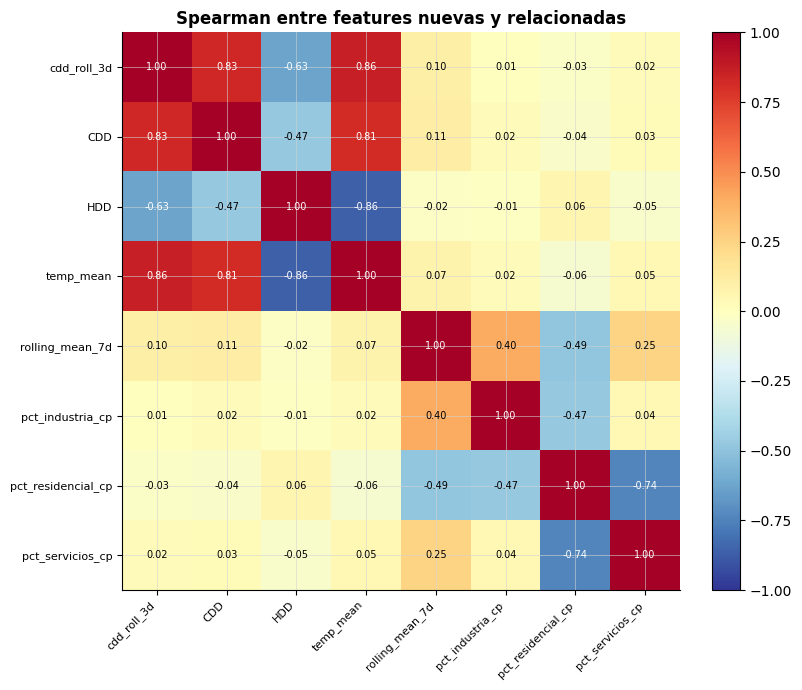

In [21]:
from scipy.stats import spearmanr

# Features nuevas + las que podrían solaparse con ellas
foco = ['cdd_roll_3d', 'CDD', 'HDD', 'temp_mean', 'rolling_mean_7d',
        'pct_industria_cp', 'pct_residencial_cp', 'pct_servicios_cp']

sub  = df.select(foco).drop_nulls().to_pandas()
corr = sub.corr(method='spearman')

print("Matriz de Spearman entre features (redundancia)")
print(corr.round(2))

print("\nSpearman de cada feature nueva con mwh_total")
for v in ['cdd_roll_3d', 'pct_industria_cp', 'pct_residencial_cp', 'pct_servicios_cp', 'HDD', 'CDD']:
    d = df.select([v, 'mwh_total']).drop_nulls()
    r = spearmanr(d[v].to_numpy(), d['mwh_total'].to_numpy()).statistic
    print(f"  {v:<22} {r:+.3f}")

# Heatmap
m = corr.values
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(m, cmap='RdYlBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(foco))); ax.set_xticklabels(foco, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(foco))); ax.set_yticklabels(foco, fontsize=8)
for i in range(len(foco)):
    for j in range(len(foco)):
        ax.text(j, i, f'{m[i, j]:.2f}', ha='center', va='center', fontsize=7,
                color='white' if abs(m[i, j]) > 0.6 else 'black')
ax.set_title('Spearman entre features nuevas y relacionadas', fontweight='bold')
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

> Chequeo de redundancia (Spearman)  interpretación
>
> Las redundancias que aparecen son **estructurales y esperables**, no problemas:
>
> - Bloque térmico (cdd_roll_3d, CDD, HDD, temp_mean): muy correlacionado entre sí (0.81–0.86) porque las cuatro derivan de la temperatura. Lo relevante es que HDD y CDD solo dan −0.47. Cada una captura una rama distinta de la U del EDA (frío  y calor), no son la misma variable invertida.
- CDD +0.152 vs HDD −0.062. El consumo eléctrico responde mucho más al calor (AC) que al frío coherente con un clima templado y caleacción mayoritariamente de gas. El Spearman bajo de temp_mean con el consumo es justo el efecto de la U (Spearman mide monotonía), que es la razón de existir de HDD/CDD.
- Bloque sectorial. pct_residencial y pct_servicios = −0.74 es composicional (los porcentajes suman ~100%). Aun así son las features más predictivas, pct_residencial −0.441 y pct_industria +0.369, confirmando que el mix de usos del CP es el driver principal.

> A vigilar en el SARIMAX (lineal): para evitar coeficientes inestables por colinealidad, tendrpe que quedarme con CDD o HDD, descartando temp_mean y cdd_roll_3d, y usar solo dos de los tres porcentajes sectoriales (dejando uno como referencia).

---
# <font color='#1B3A5C'>  **Conclusiones del Feature Engineering** </font>

> Features construidas (17):

- **Climáticas derivadas:** HDD, CDD (descomposición de la U térmica en dos rampas), cdd_roll_3d (inercia térmica de 3 días), lst_nublado
  y precipitacion_llueve (huecos y precipitación convertidos en señal binaria).
- **Temporales:** lag_1, lag_2, lag_3, lag_4, lag_28, rolling_mean_7d y rolling_std_7d, construidos
  por CP sin data leakage. lag_2/lag_3 completan el día anterior; rolling_std_7d aporta volatilidad para la alerta temprana.
- **Perfil sectorial (por CP):** pct_industria_cp, pct_residencial_cp y pct_servicios_cp, media móvil rezagada de 12 meses que resume la identidad estructural del barrio sin leakage ni estacionalidad.
- **Interacción y control:** hora_x_finde (amplificación diurna del calendario) e is_covid
  (cambio estructural 2020).

> Imputación resuelta:

- Nulos estructurales de X2 (viento, irradiancia, temp/humedad 2024-2025) imputados desde X4
  con factor de corrección mensual. Irradiancia negativa topada a 0.

> Decisiones heredadas del EDA:

- temp_max y temp_min descartadas por colinealidad (0.95-0.99 con temp_mean).
- Sectores mwh_industria/residencial/servicios excluidos por data leakage (componentes del target).
- cod_postal se mantiene como categórica, el factor más discriminante (Kruskal-Wallis H=279.152).

> Línea futura:

- lag1_vecinos (consumo de CPs colindantes en t-1 vía shapely sobre BARCELONA.geojson),
  deprioritizado por restricción de tiempo.
- Combinar MODIS Terra+Aqua para obtener LST por bloque diurno.

> El dataset_features queda listo para la fase de modelado: SARIMA como baseline, XGBoost/LightGBM
> y LSTM/GRU.